In [ ]:
!pip install roboflow -q
from roboflow import Roboflow
rf = Roboflow(api_key="w7eJKlBJbmuTlDzxyZjU")
proj1 = rf.workspace("screw-rvtnf").project("screw-gywcj")
proj1.version(2).download("yolo11", location="/content/datasets/screw1")
proj2 = rf.workspace("rf-projects").project("screw-placement")
proj2.version(1).download("yolo11", location="/content/datasets/screw2")
proj3 = rf.workspace("akira-inaba").project("screws-g4zwf")
proj3.version(1).download("yolo11", location="/content/datasets/screw3")
print("All 3 Roboflow datasets downloaded")


loading Roboflow workspace...
loading Roboflow project...

Version export complete for yolo11 format



Extracting Dataset Version Zip to /content/datasets/screw1 in yolo11:: 100%|██████████| 1517/1517 [00:00<00:00, 7331.57it/s]

loading Roboflow workspace...


loading Roboflow project...

Version export complete for yolo11 format



Extracting Dataset Version Zip to /content/datasets/screw2 in yolo11:: 100%|██████████| 622/622 [00:00<00:00, 9072.01it/s]

loading Roboflow workspace...


loading Roboflow project...

Version export complete for yolo11 format



Extracting Dataset Version Zip to /content/datasets/screw3 in yolo11:: 100%|██████████| 752/752 [00:00<00:00, 9468.52it/s]

All 3 Roboflow datasets downloaded


In [ ]:
# @title
# ── Save checkpoints to Drive immediately after training ────────────────
import shutil, os

RUNS_DIR  = '/content/runs/detect/screw_yoloe_combined/weights'
DRIVE_DIR = '/content/drive/MyDrive/WDSD_combined'

for fname in ['best.pt', 'last.pt']:
    src = f'{RUNS_DIR}/{fname}'
    dst = f'{DRIVE_DIR}/{fname}'
    if os.path.exists(src):
        shutil.copy(src, dst)
        size = os.path.getsize(dst) / 1e6
        print(f"{fname} → Drive  ({size:.1f} MB)")
    else:
        print(f"{fname} not found in runs dir")


best.pt → Drive  (60.6 MB)
last.pt not found in runs dir


In [ ]:
# @title
# ── Quick inference test on 6 test images ───────────────────────────────
from ultralytics import YOLOE
from PIL import Image
import matplotlib.pyplot as plt
import os

model = YOLOE('/content/drive/MyDrive/WDSD_combined/best.pt')

test_dir = '/content/drive/MyDrive/WDSD_combined/images/test'
test_imgs = [os.path.join(test_dir, f) for f in os.listdir(test_dir)[:6]]

results = model.predict(test_imgs, conf=0.25, imgsz=1280)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
for i, r in enumerate(results):
    r.save(f'/content/test_result_{i}.jpg')
    axes[i//3][i%3].imshow(Image.open(f'/content/test_result_{i}.jpg'))
    axes[i//3][i%3].set_title(f"Screws detected: {len(r.boxes)}", fontsize=13)
    axes[i//3][i%3].axis('off')

plt.suptitle('YOLOE-26 Combined — Screw Detection Results', fontsize=15)
plt.tight_layout()
plt.show()

print("\nDETECTION SUMMARY")
for i, r in enumerate(results):
    print(f"  Image {i+1}: {len(r.boxes)} screws")


ModuleNotFoundError: No module named 'ultralytics'

In [ ]:
import os, shutil, yaml
from roboflow import Roboflow
ROBOFLOW_API_KEY = "w7eJKlBJbmuTlDzxyZjU"
DRIVE_NEW        = '/content/drive/MyDrive/NEW_SCREW_DATASET'

rf      = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("juca-pqthg").project("yolo-screw-detection-5fvxu")
dataset = project.version(2).download("yolo26", location="/content/new_screw_raw")
print("Download complete")

yaml_path = "/content/new_screw_raw/data.yaml"
with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

print("Original yaml:", data)

data['nc']    = 1
data['names'] = ['screw']
data['train'] = f'{DRIVE_NEW}/images/train'
data['val']   = f'{DRIVE_NEW}/images/val'
data['test']  = f'{DRIVE_NEW}/images/test'

with open(yaml_path, 'w') as f:
    yaml.dump(data, f)

if os.path.exists(DRIVE_NEW):
    shutil.rmtree(DRIVE_NEW)
shutil.copytree("/content/new_screw_raw", DRIVE_NEW)
print(f"Saved to Drive: {DRIVE_NEW}")

for split in ['train', 'val', 'test']:
    img_dir = f'{DRIVE_NEW}/images/{split}'
    lbl_dir = f'{DRIVE_NEW}/labels/{split}'
    if os.path.exists(img_dir):
        imgs   = len(os.listdir(img_dir))
        labels = len(os.listdir(lbl_dir)) if os.path.exists(lbl_dir) else 0
        print(f"  {split}: {imgs} images, {labels} labels")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/new_screw_raw in yolo26:: 100%|██████████| 818/818 [00:00<00:00, 7546.13it/s]


Download complete
Original yaml: {'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 9, 'names': ['allen_chico', 'allen_largo', 'allen_mediano', 'hex_chico', 'hex_largo', 'hex_mediano', 'plano_chico', 'plano_largo', 'plano_mediano'], 'roboflow': {'workspace': 'juca-pqthg', 'project': 'yolo-screw-detection-5fvxu', 'version': 2, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/juca-pqthg/yolo-screw-detection-5fvxu/dataset/2'}}
Saved to Drive: /content/drive/MyDrive/NEW_SCREW_DATASET


In [1]:
from google.colab import drive
drive.mount('/content/drive')
# import os
# COMBINED = '/content/drive/MyDrive/WDSD_combined'
# assert os.path.exists(COMBINED), f"WDSD_combined not found at {COMBINED}"
# print(f"WDSD_combined found")
# print(f"  train images : {len(os.listdir(f'{COMBINED}/images/train'))}")
# print(f"  val   images : {len(os.listdir(f'{COMBINED}/images/val'))}")
# print(f"  test  images : {len(os.listdir(f'{COMBINED}/images/test'))}")


Mounted at /content/drive


In [ ]:
# @title
import os, shutil
from ultralytics import YOLOE
from ultralytics.models.yolo.yoloe import YOLOEPETrainer

DRIVE_DIR    = '/content/drive/MyDrive/WDSD_combined'
NEW_DATA_DIR = '/content/drive/MyDrive/NEW_SCREW_DATASET'
RUN_NAME     = 'screw_yoloe_finetune'
RUNS_DIR     = f'/content/runs/detect/{RUN_NAME}/weights'

BACKUP_EVERY_N_EPOCHS = 5

def backup_to_drive(trainer):
    epoch = trainer.epoch + 1
    if epoch % BACKUP_EVERY_N_EPOCHS == 0:
        os.makedirs(DRIVE_DIR, exist_ok=True)
        if os.path.exists(f'{RUNS_DIR}/last.pt'):
            shutil.copy(f'{RUNS_DIR}/last.pt', f'{DRIVE_DIR}/finetune_last.pt')
            print(f"  [Drive backup] finetune_last.pt at epoch {epoch}")
        if os.path.exists(f'{RUNS_DIR}/best.pt'):
            shutil.copy(f'{RUNS_DIR}/best.pt', f'{DRIVE_DIR}/finetune_best.pt')

model = YOLOE(f'{DRIVE_DIR}/best.pt')
model.add_callback('on_fit_epoch_end', backup_to_drive)  # ← on model, not trainer

model.train(
    trainer  = YOLOEPETrainer,   # ← pass class, not instance
    data     = f'{NEW_DATA_DIR}/data.yaml',
    epochs   = 30,
    imgsz    = 1280,
    batch    = 4,
    device   = 'cuda',
    name     = RUN_NAME,
    patience = 10,
    lr0      = 0.001,
    lrf      = 0.01,
    freeze   = 10,
    save     = True,
    plots    = True,
)

print("\nFine-tuning complete")
print(f"Best model: {DRIVE_DIR}/finetune_best.pt")

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/NEW_SCREW_DATASET/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/WDSD_combined/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=screw_yoloe_finetune3, nbs=64, nms=False, opset=None, optimize=

In [2]:
!pip install ultralytics roboflow -q
print("Dependencies installed")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 139.0 MB/s eta 0:00:00
Dependencies installed


Loaded: /content/drive/MyDrive/WDSD_combined/finetune_best.pt


Saving s2_torx_closeup_hd30_cropped_1_jpg.rf.4d7d1c75453becb525554cbea1ae9f8d.jpg to s2_torx_closeup_hd30_cropped_1_jpg.rf.4d7d1c75453becb525554cbea1ae9f8d (1).jpg

image 1/1 /content/s2_torx_closeup_hd30_cropped_1_jpg.rf.4d7d1c75453becb525554cbea1ae9f8d (1).jpg: 1280x1280 3 screws, 50.9ms
Speed: 11.8ms preprocess, 50.9ms inference, 0.7ms postprocess per image at shape (1, 3, 1280, 1280)

Screws detected: 3


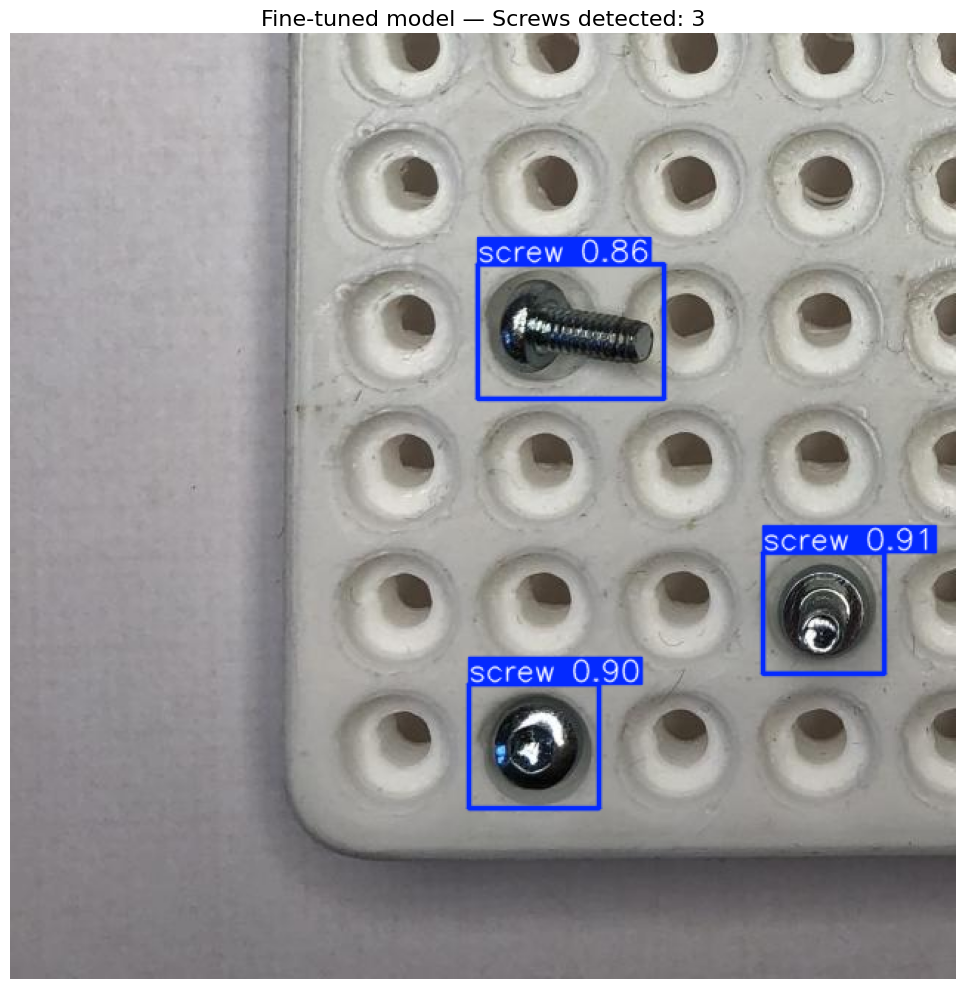

In [12]:
import os, shutil
from ultralytics import YOLOE
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files

# ── Save finetune_best to Drive if not already there ──────────
# local_best = '/content/runs/detect/screw_yoloe_finetune3/weights/best.pt'
drive_best = '/content/drive/MyDrive/WDSD_combined/finetune_best.pt'

# if not os.path.exists(drive_best):
    # shutil.copy(local_best, drive_best)
    # print("Saved finetune_best.pt to Drive")

# ── Load fine-tuned model ─────────────────────────────────────
model = YOLOE(drive_best)
print(f"Loaded: {drive_best}")

# ── Upload and test ───────────────────────────────────────────
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

results = model.predict(
    source=img_path,
    imgsz=1280,
    conf=0.7,
    iou=0.5,
    device='cuda',
    save=False,
)

result = results[0]
screw_count = len(result.boxes)
print(f"\nScrews detected: {screw_count}")

annotated = result.plot()
plt.figure(figsize=(14, 10))
plt.imshow(annotated[..., ::-1])
plt.axis('off')
plt.title(f"Fine-tuned model — Screws detected: {screw_count}", fontsize=16)
plt.tight_layout()
plt.show()